# Før du går i gang
**Vigtigt:** Lav først din egen kopi af denne notebook.

Vælg:
**File → Save a copy in Drive**

Du skal herefter arbejde i kopien i dit eget Google Drive.

Du behøver ikke bruge GitHub eller Git.


# Kode GNSS øvelse

## Indledende kode
Først skal vi importere de moduler vi skal bruge til at beregne og visualisere vores observationer.

In [28]:
from math import sqrt
from numpy import array, linspace
from matplotlib import pyplot as plt
from pyproj import Transformer
import matplotlib
matplotlib.rcParams['axes.formatter.useoffset'] = False
matplotlib.rcParams['axes.formatter.limits'] = (-5, 8)
from scipy import stats
import numpy as np

## Observationer
Vi skal nu indtaste vores observationer så Python kan regne på dem.

Først indtastes den sande koordinat *posTrue* fra fikspunktsbeskrivelsen.
Observationerne indtastes i *gnssObs* som er et array (struktureret talbeholder) før de endelige beregninger foretages.
Bemærk at Python, som de fleste programmeringssprog bruger punktum som decimalseperator i stedet for komma.
Komma bruges til at separere elementer.

Det er desuden vigtigt at overholde rækkefølgen; Easting, Northing, Højde
I eksemplet herunder er der indtastet tre observationer af en koordinat.
Bemærk at *len* kommandoen tæller hvor mange elementer med 3 underelementer der er i listen.

In [ ]:
def dmsdot_to_dd(coord):
    """
    Convert DD.MM.SSSS format to decimal degrees.

    Example:
    66.55.9978 -> 66 + 55.9978/60
    """
    deg, minutes, frac = str(coord).strip().split(".")
    dec_minutes = float(f"{minutes}.{frac}")
    return float(deg) + dec_minutes / 60.0

def latlonh_to_utm22(obs):
    """
    Function til at konveretere fra lat lon h til UTM22N
        [lat, lon, h]

    where lat/lon are in Greenland DD.MM.SSSS format

    to:
        [E, N, h]

    in UTM Zone 22N (EPSG:32622)
    """

    transformer = Transformer.from_crs(
        "EPSG:4326",
        "EPSG:32622",
        always_xy=True
    )

    utm_obs = []

    for lat, lon, h in obs:
        lat_dd = dmsdot_to_dd(lat)

        # Greenland longitudes are west
        lon_dd = -dmsdot_to_dd(lon)

        E, N = transformer.transform(lon_dd, lat_dd)

        utm_obs.append([E, N, h])

    return np.array(utm_obs)

# Sand position
posTrue = np.array([383244.680, 7426448.035, 89.648])

# Indsæt jeres obervsationer her: Dette eksempel er fra Fixpunkt 62052
gnssObs_latlonh = np.array([
    ["66.55.9978", "53.40.2665", 70],
    ["66.55.9978", "53.40.2656", 70],
    ["66.55.9976", "53.40.2667", 70],
    ["66.55.9971", "53.40.2665", 70],
    ["66.55.9966", "53.40.2655", 70],
    ["66.55.9967", "53.40.2656", 70],
    ["66.55.9969", "53.40.2656", 70],
    ["66.55.9968", "53.40.2658", 70],
    ["66.55.9968", "53.40.2655", 70],
    ["66.55.9967", "53.40.2656", 70]
], dtype=object)

# konverter fra latlonh til UTM22N
gnssObs = latlonh_to_utm22(gnssObs_latlonh)

count = len(gnssObs)

print("\ngnssObs =")
print(gnssObs)

# Antal observationer 
print("\nCount =", count)


gnssObs =
[[3.83243476e+05 7.42644881e+06 7.00000000e+01]
 [3.83244131e+05 7.42644878e+06 7.00000000e+01]
 [3.83243315e+05 7.42644844e+06 7.00000000e+01]
 [3.83243420e+05 7.42644751e+06 7.00000000e+01]
 [3.83244109e+05 7.42644655e+06 7.00000000e+01]
 [3.83244044e+05 7.42644674e+06 7.00000000e+01]
 [3.83244060e+05 7.42644711e+06 7.00000000e+01]
 [3.83243906e+05 7.42644693e+06 7.00000000e+01]
 [3.83244125e+05 7.42644692e+06 7.00000000e+01]
 [3.83244044e+05 7.42644674e+06 7.00000000e+01]]

Count = 10


## Visuel vurdering af observationer


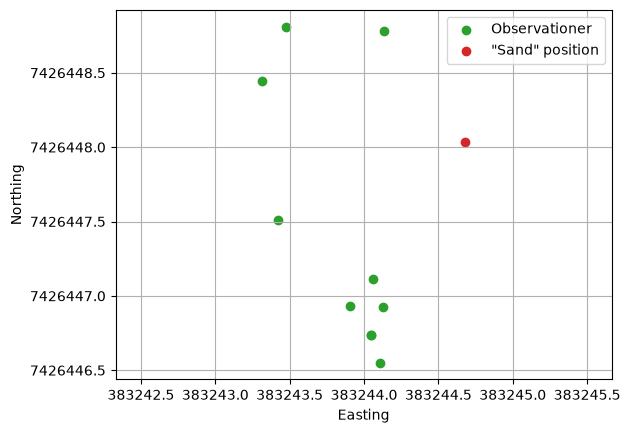

In [ ]:
# Lav et plot af jeres positioner. I kan bruge nedenstående som eksempel. Eksperimenter gerne med farver, akser, mm. 
plt.figure()
plt.scatter(gnssObs[:, 0], gnssObs[:, 1], color='tab:green', label=f'Observationer')
plt.scatter(posTrue[0], posTrue[1], color='tab:red', label=f'"Sand" position')
plt.xlabel('Easting')
plt.ylabel('Northing')
plt.legend()
plt.axis('equal')
plt.grid(True)

plt.show()


## Beregning af middelværdier og spredning

In [ ]:
## Middelværdier
eastMean = ?
northMean = ?
heightMean = ?

# beregning af spredning
eastStd =?
northStd = ?
heightStd = ?

0.32543863817658003


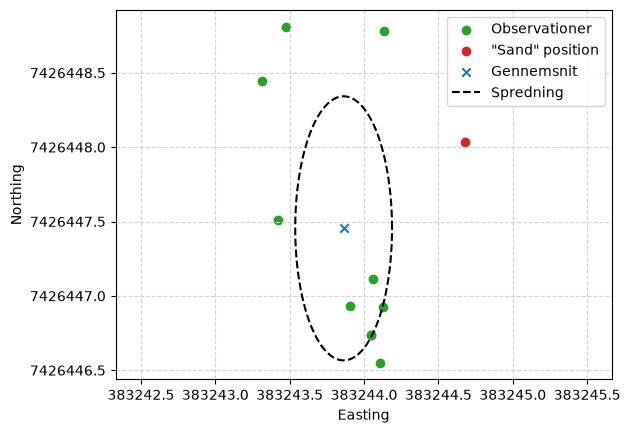

In [32]:
## Definition af visualiserings-variable fra ovenstående blok 
u = eastMean    # x-position af midtpunktet
v = northMean  # y-position af midtpunktet
a = eastStd     # radius på x-aksen
b = northStd    # radius på y-aksen

# visualisering af måling
plt.figure()
plt.scatter(gnssObs[:, 0], gnssObs[:, 1], color='tab:green', label=f'Observationer')
plt.scatter(posTrue[0], posTrue[1], color='tab:red', label=f'"Sand" position') 
plt.scatter(u,v,marker='x',label=f'Gennemsnit') # gennemsnit visualiseret med et x
t = np.linspace(0, 2*np.pi, 100) # variabel til at definere en omgang med en cirkel
plt.plot( u+a*np.cos(t) , v+b*np.sin(t),color='black',linestyle='--', label=f'Spredning') # spredning visualiseret med en cirkel
plt.grid(color='lightgray',linestyle='--')
plt.xlabel('Easting')
plt.ylabel('Northing')
plt.legend(bbox_to_anchor=(1,1))
plt.axis('equal')
plt.grid(True)
plt.show()

## Plot fordelinger for observationerne

Easting:   383243.863 m +/-0.325 m
Northing: 7426447.454 m +/-0.888 m
Højde:         70.000 m +/-0.000 m


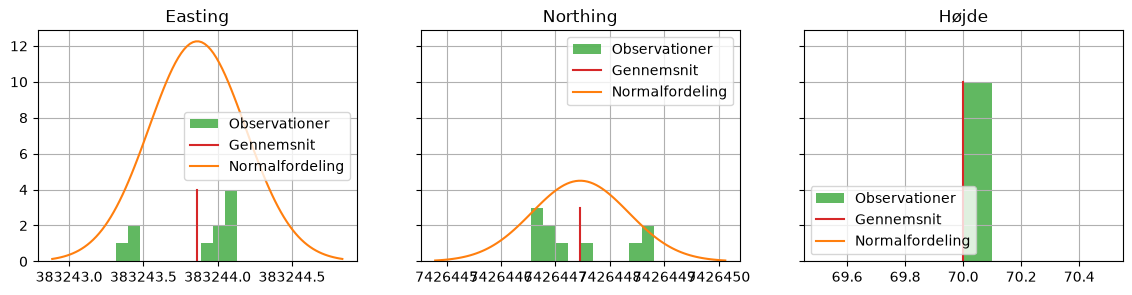

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3), sharey=True)     #Start af figur

x = linspace(eastMean - 3 * eastStd, eastMean + 3 * eastStd, 100)       # linspace generere ligeligt fordelte punkter mellem de to første inputs.

# Histogram over easting observationer
n, bins, patches = axs[0].hist(gnssObs[:, 0], 10, density=False, facecolor='tab:green', alpha=0.75, label=f'Observationer')         # Visualisering af observationer ved histogram 
axs[0].plot([eastMean, eastMean], [0, max(n)], color='tab:red', label=f'Gennemsnit')                                                # Visualisering af gennemnsittet af observationerne
axs[0].plot(x, stats.norm.pdf(x, eastMean, eastStd) * count, color='tab:orange', label=f'Normalfordeling')                          # Beregningen af normal fordelingen af observationer
axs[0].set_title('Easting')
axs[0].legend()
axs[0].grid(True)

# Histogram over northing observationer
x = linspace(northMean - 3 * northStd, northMean + 3 * northStd, 100)
n, bins, patches = axs[1].hist(gnssObs[:, 1], 10, density=False, facecolor='tab:green', alpha=0.75, label=f'Observationer')         # Visualisering af observationer ved histogram
axs[1].plot([northMean, northMean], [0, max(n)], color='tab:red', label=f'Gennemsnit')                                              # Visualisering af gennemnsittet af observationerne
axs[1].plot(x, stats.norm.pdf(x, northMean, northStd) * count, color='tab:orange', label=f'Normalfordeling')                        # Beregningen af normal fordelingen af observationer
axs[1].legend()
axs[1].set_title('Northing')
axs[1].grid(True)

# Histogram over højde observationer
x = linspace(heightMean - 3 * heightStd, heightMean + 3 * heightStd, 100)
n, bins, patches = axs[2].hist(gnssObs[:, 2], 10, density=False, facecolor='tab:green', alpha=0.75, label=f'Observationer')         # Visualisering af observationer ved histogram
axs[2].plot([heightMean, heightMean], [0, max(n)], color='tab:red', label=f'Gennemsnit')                                            # Visualisering af gennemnsittet af observationerne
axs[2].plot(x, stats.norm.pdf(x, heightMean, heightStd) * count, color='tab:orange', label=f'Normalfordeling')                      # Beregningen af normal fordelingen af observationer
axs[2].legend()
axs[2].set_title('Højde')
axs[2].grid(True)

#axs[...].plot() bruges til at sætte plots op ved siden af hinanden, i modsætningen til plt.plot() der generere et enkeltstående plot.

print(f"Easting:  {eastMean:11.3f} m +/-{eastStd:.3f} m")      # print function, der printer eastmean m. 3 decimaler, og eastSTD med 3 decimaler. 
print(f"Northing: {northMean:11.3f} m +/-{northStd:.3f} m")
print(f"Højde:    {heightMean:11.3f} m +/-{heightStd:.3f} m")

## Kommentarer til resultaterne
Her skal I bruge 1/2 - 1 side på at beskrive jeres resultater.

f.eks:
  - Hvor tæt kom I på den faktiske koordinat?
  - Hvor stor er spredningen?
  - Stemmer resultaterne overens med det forventede i forhold til fejlteori og GNSS teori?
  - Skiller nogle observationer sig ud?